In [25]:
import pandas as pd

data=pd.read_csv('Data/Train.csv')
data1=pd.read_csv('Data/Train2.csv')
data2=pd.read_csv('Data/Train3.csv')
data3=pd.read_csv('Data/Train4.csv')
list_of_dfs = [data, data1, data2, data3]
train_data = pd.concat(list_of_dfs, ignore_index=True)

In [26]:

train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3574871 entries, 0 to 3574870
Data columns (total 10 columns):
 #   Column            Dtype  
---  ------            -----  
 0   user_session      str    
 1   total_carts       int64  
 2   total_removes     int64  
 3   total_views       int64  
 4   session_duration  float64
 5   avg_price         float64
 6   max_price         float64
 7   unique_products   int64  
 8   unique_brands     int64  
 9   is_purchased      int64  
dtypes: float64(3), int64(6), str(1)
memory usage: 395.5 MB


Ta chọn mô hình cơ sở là logistics regression

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
# Loại bỏ cột định danh 'user_session' và cột nhãn 'is_purchased' khỏi X
X = train_data.drop(columns=['user_session', 'is_purchased','avg_price','max_price'])
y = train_data['is_purchased']

# 2. Chia dữ liệu thành tập huấn luyện (train) và tập kiểm tra (test)
# test_size=0.2 nghĩa là dùng 20% dữ liệu để kiểm tra, 80% để huấn luyện
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Chuẩn hóa dữ liệu (Feature Scaling)
scaler = StandardScaler()
# Chỉ fit trên tập train để tránh rò rỉ dữ liệu (data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(random_state=19)
model.fit(X_train_scaled, y_train)

# 5. Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test_scaled)

# 6. Đánh giá mô hình
print("=== ĐỘ CHÍNH XÁC (Accuracy) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("=== BÁO CÁO PHÂN LỚP (Classification Report) ===")
print(classification_report(y_test, y_pred))

print("=== MA TRẬN NHẦM LẪN (Confusion Matrix) ===")
print(confusion_matrix(y_test, y_pred))

=== ĐỘ CHÍNH XÁC (Accuracy) ===
Accuracy: 0.9678

=== BÁO CÁO PHÂN LỚP (Classification Report) ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    692655
           1       0.38      0.05      0.09     22320

    accuracy                           0.97    714975
   macro avg       0.68      0.52      0.54    714975
weighted avg       0.95      0.97      0.96    714975

=== MA TRẬN NHẦM LẪN (Confusion Matrix) ===
[[690759   1896]
 [ 21144   1176]]


Tối ưu F1 bằng cách tìm ngưỡng tối ưu

In [53]:
model = LogisticRegression(random_state=19)
model.fit(X_train_scaled, y_train)

# ==========================================
# 5. DỰ ĐOÁN VÀ HẠ NGƯỠNG QUYẾT ĐỊNH
# ==========================================
# THAY THẾ lệnh predict() mặc định bằng predict_proba()
# [:, 1] nghĩa là ta chỉ lấy cột Xác suất của Lớp 1 (Có mua hàng)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# THIẾT LẬP NGƯỠNG MỚI (Ví dụ: Hạ xuống 0.15 tức là 15%)
custom_threshold = 0.15

# Nếu xác suất >= ngưỡng thì gán thành 1, ngược lại là 0
y_pred_custom = (y_prob >= custom_threshold).astype(int)


# ==========================================
# 6. ĐÁNH GIÁ MÔ HÌNH VỚI NGƯỠNG MỚI
# ==========================================
print(f"=== ĐÁNH GIÁ MÔ HÌNH VỚI NGƯỠNG THRESHOLD = {custom_threshold} ===")
print("=== ĐỘ CHÍNH XÁC (Accuracy) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}\n")

print("=== BÁO CÁO PHÂN LỚP (Classification Report) ===")
print(classification_report(y_test, y_pred_custom))

print("=== MA TRẬN NHẦM LẪN (Confusion Matrix) ===")
print(confusion_matrix(y_test, y_pred_custom))

=== ĐÁNH GIÁ MÔ HÌNH VỚI NGƯỠNG THRESHOLD = 0.15 ===
=== ĐỘ CHÍNH XÁC (Accuracy) ===
Accuracy: 0.9607

=== BÁO CÁO PHÂN LỚP (Classification Report) ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    692655
           1       0.29      0.18      0.23     22320

    accuracy                           0.96    714975
   macro avg       0.63      0.58      0.60    714975
weighted avg       0.95      0.96      0.96    714975

=== MA TRẬN NHẦM LẪN (Confusion Matrix) ===
[[682781   9874]
 [ 18225   4095]]


Tìm ngưỡng cho F1 tối đa

In [54]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# ==========================================
# 4. HUẤN LUYỆN MÔ HÌNH
# ==========================================
# LƯU Ý: Vẫn nên thêm class_weight='balanced' để mô hình khởi điểm thông minh hơn
model = LogisticRegression(class_weight='balanced', random_state=19)
model.fit(X_train_scaled, y_train)

# Lấy xác suất dự đoán của Lớp 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# 5. THUẬT TOÁN TỰ ĐỘNG DÒ TÌM NGƯỠNG TỐI ƯU
# ==========================================
print("Đang chạy thuật toán tự động dò tìm Ngưỡng tối ưu...")

best_threshold = 0.5
best_f1 = 0

# Tạo một danh sách các ngưỡng từ 0.01 đến 0.99, mỗi bước nhảy là 0.01
thresholds = np.arange(0.01, 1.00, 0.01)

# Cho máy tính tự động quét qua từng ngưỡng
for thresh in thresholds:
    # Thử ép nhãn với ngưỡng hiện tại
    y_pred_temp = (y_prob >= thresh).astype(int)
    
    # Tính điểm F1 với ngưỡng này
    current_f1 = f1_score(y_test, y_pred_temp)
    
    # Nếu F1 của ngưỡng này cao hơn kỷ lục cũ -> Lưu lại làm kỷ lục mới
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"\n=> TÌM THẤY NGƯỠNG TỐI ƯU (BEST THRESHOLD): {best_threshold:.2f}")
print(f"=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: {best_f1:.4f}\n")

# ==========================================
# 6. ĐÁNH GIÁ MÔ HÌNH VỚI NGƯỠNG VỪA TÌM ĐƯỢC
# ==========================================
# Chốt kết quả dự đoán với cái ngưỡng xịn nhất vừa tìm được
y_pred_optimal = (y_prob >= best_threshold).astype(int)

print(f"=== BÁO CÁO PHÂN LỚP VỚI NGƯỠNG {best_threshold:.2f} ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}\n")
print(classification_report(y_test, y_pred_optimal))

print("=== MA TRẬN NHẦM LẪN ===")
print(confusion_matrix(y_test, y_pred_optimal))

Đang chạy thuật toán tự động dò tìm Ngưỡng tối ưu...

=> TÌM THẤY NGƯỠNG TỐI ƯU (BEST THRESHOLD): 0.73
=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: 0.3234

=== BÁO CÁO PHÂN LỚP VỚI NGƯỠNG 0.73 ===
Accuracy: 0.9358

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    692655
           1       0.24      0.49      0.32     22320

    accuracy                           0.94    714975
   macro avg       0.61      0.72      0.64    714975
weighted avg       0.96      0.94      0.95    714975

=== MA TRẬN NHẦM LẪN ===
[[658123  34532]
 [ 11353  10967]]


Lưu model

In [56]:
import joblib
model_bundle = {
    'model': model,
    'scaler': scaler,             # Đừng quên lưu cả scaler nhé
    'best_threshold': best_threshold
}

# Lưu Dictionary này ra file
joblib.dump(model_bundle, 'logistic_model_bundle.pkl')

['logistic_model_bundle.pkl']

Cây quyết định

Đang huấn luyện mô hình Cây quyết định (Decision Tree)...
Đang tự động dò tìm Ngưỡng tối ưu (Threshold Tuning)...

=> TÌM THẤY NGƯỠNG TỐI ƯU: 0.88
=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: 0.3529

=== BÁO CÁO PHÂN LỚP (NGƯỠNG = 0.88) ===
Accuracy: 0.9406

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    692655
           1       0.27      0.52      0.35     22320

    accuracy                           0.94    714975
   macro avg       0.63      0.74      0.66    714975
weighted avg       0.96      0.94      0.95    714975



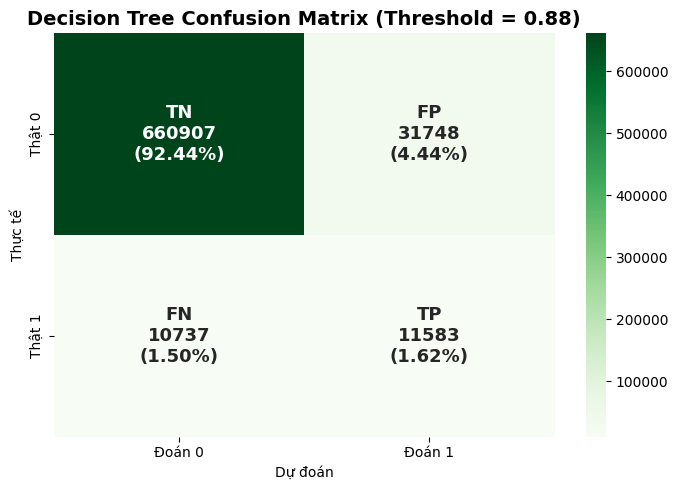

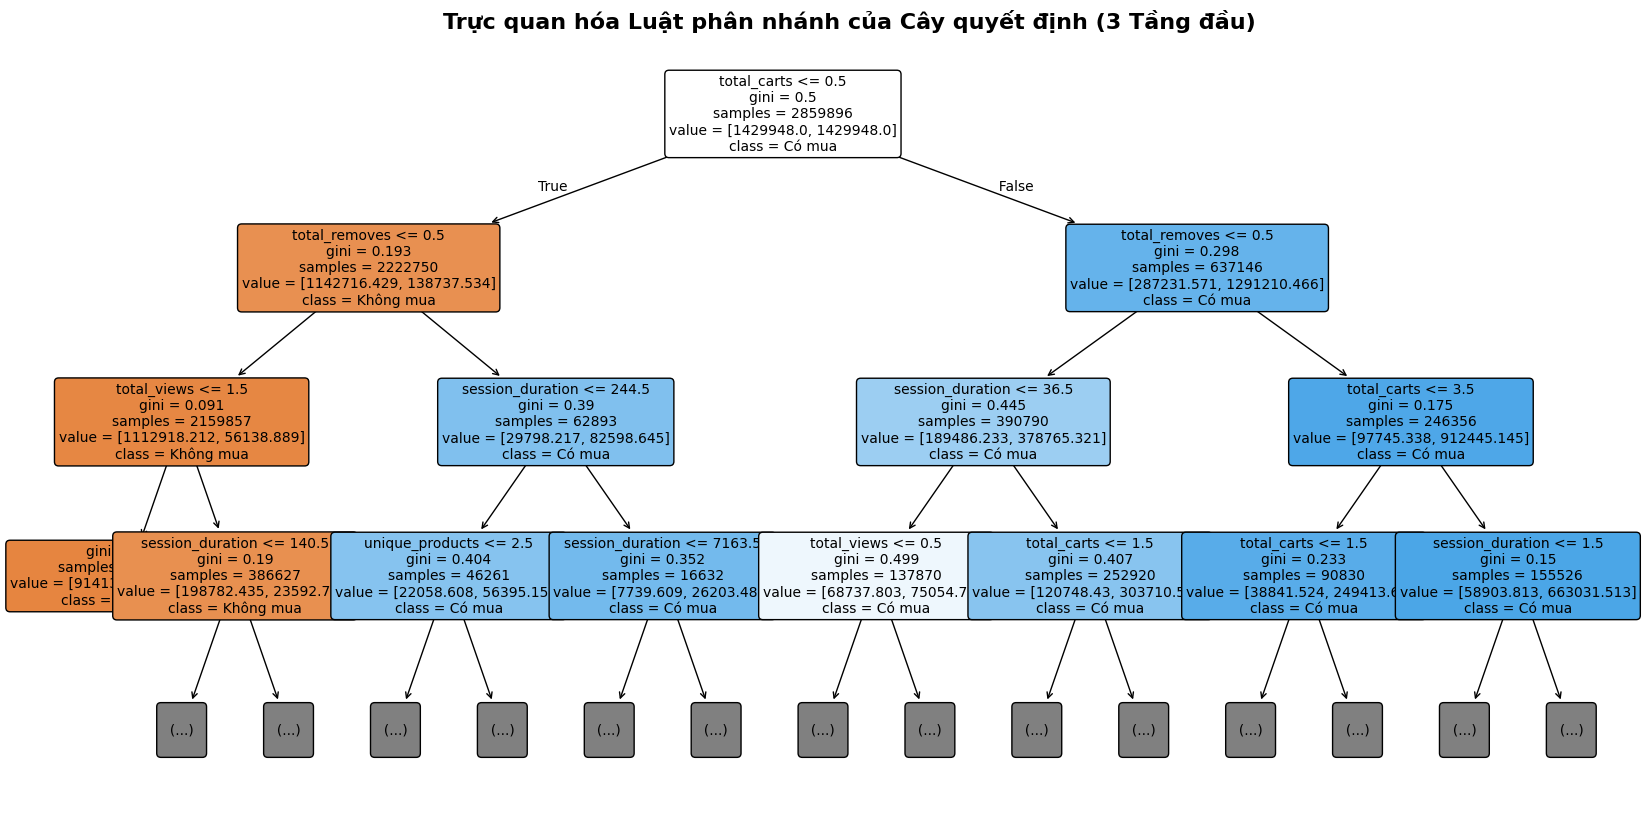

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH CÂY QUYẾT ĐỊNH
# ==========================================
print("Đang huấn luyện mô hình Cây quyết định (Decision Tree)...")

# Lưu ý: Cây quyết định KHÔNG CẦN chuẩn hóa dữ liệu (StandardScaler). 
# Bạn dùng trực tiếp X_train gốc cũng được, hoặc dùng X_train_scaled đều không ảnh hưởng.
dt_model = DecisionTreeClassifier(
    max_depth=8,               # CỰC KỲ QUAN TRỌNG: Giới hạn độ sâu để chống Overfitting
    class_weight='balanced',   # Tự động xử lý mất cân bằng lớp
    random_state=42
)

dt_model.fit(X_train, y_train)

# Lấy xác suất dự đoán của Lớp 1 (Có mua hàng)
# Xác suất của Cây quyết định = (Số người mua) / (Tổng số người) nằm trong cái lá cuối cùng
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# ==========================================
# 2. THUẬT TOÁN TỰ ĐỘNG DÒ TÌM NGƯỠNG TỐI ƯU
# ==========================================
print("Đang tự động dò tìm Ngưỡng tối ưu (Threshold Tuning)...")

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.01, 1.00, 0.01)

# Quét qua 100 ngưỡng để tìm F1 cao nhất
for thresh in thresholds:
    y_pred_temp = (y_prob_dt >= thresh).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"\n=> TÌM THẤY NGƯỠNG TỐI ƯU: {best_threshold:.2f}")
print(f"=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: {best_f1:.4f}\n")

# ==========================================
# 3. ĐÁNH GIÁ MÔ HÌNH VỚI NGƯỠNG VỪA TÌM ĐƯỢC
# ==========================================
y_pred_optimal = (y_prob_dt >= best_threshold).astype(int)

print(f"=== BÁO CÁO PHÂN LỚP (NGƯỠNG = {best_threshold:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}\n")
print(classification_report(y_test, y_pred_optimal))

# ==========================================
# 4. VẼ MA TRẬN NHẦM LẪN
# ==========================================
cm = confusion_matrix(y_test, y_pred_optimal)
cm_percentage = cm.astype('float') / cm.sum() * 100

labels = [f"TN\n{cm[0,0]}\n({cm_percentage[0,0]:.2f}%)",
          f"FP\n{cm[0,1]}\n({cm_percentage[0,1]:.2f}%)",
          f"FN\n{cm[1,0]}\n({cm_percentage[1,0]:.2f}%)",
          f"TP\n{cm[1,1]}\n({cm_percentage[1,1]:.2f}%)"]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Greens',
            xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thật 0', 'Thật 1'],
            annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Decision Tree Confusion Matrix (Threshold = {best_threshold:.2f})', fontsize=14, fontweight='bold')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()

# ==========================================
# 5. [ĐIỂM A+] VẼ CÂY QUYẾT ĐỊNH (3 Tầng đầu tiên)
# ==========================================
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          class_names=['Không mua', 'Có mua'], 
          filled=True, 
          max_depth=3, # Chỉ vẽ 3 tầng đầu cho dễ nhìn
          rounded=True,
          fontsize=10)
plt.title("Trực quan hóa Luật phân nhánh của Cây quyết định (3 Tầng đầu)", fontsize=16, fontweight='bold')
plt.savefig('decision_tree_rules.png', dpi=300)
plt.show()

Đang huấn luyện mô hình Rừng ngẫu nhiên (Random Forest)...
Đang tự động dò tìm Ngưỡng tối ưu (Threshold Tuning)...

=> TÌM THẤY NGƯỠNG TỐI ƯU: 0.87
=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: 0.3562

=== BÁO CÁO PHÂN LỚP (NGƯỠNG = 0.87) ===
Accuracy: 0.9411

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    692655
           1       0.27      0.52      0.36     22320

    accuracy                           0.94    714975
   macro avg       0.63      0.74      0.66    714975
weighted avg       0.96      0.94      0.95    714975



C:\Users\hoang\AppData\Local\Temp\ipykernel_20732\3336913952.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma', ax=axes[1])


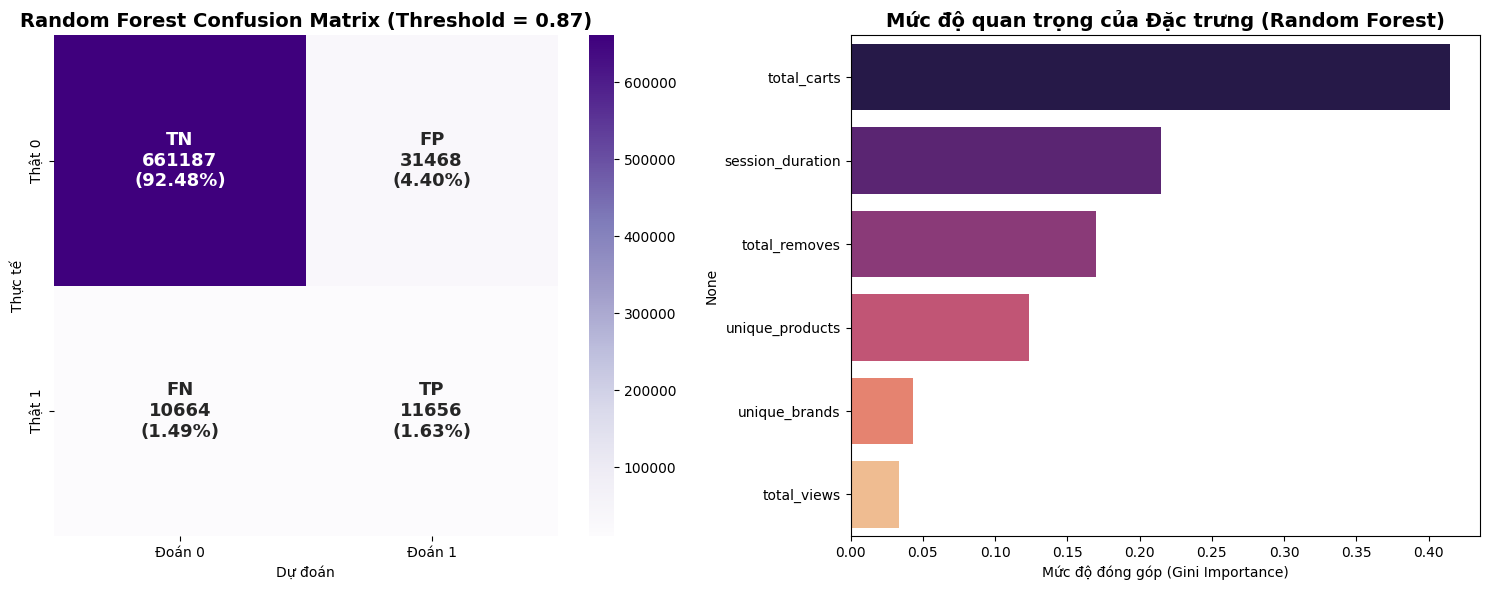

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

# ==========================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN RANDOM FOREST
# ==========================================
print("Đang huấn luyện mô hình Rừng ngẫu nhiên (Random Forest)...")

rf_model = RandomForestClassifier(
    n_estimators=150,                  # Số lượng cây trong rừng (150 cây)
    max_depth=12,                      # Giới hạn độ sâu để chống quá khớp và chạy nhanh hơn
    class_weight='balanced_subsample', # Cực kỳ quan trọng: Cân bằng trọng số trên từng cây
    random_state=42,
    n_jobs=-1                          # Dùng toàn bộ nhân CPU để tăng tốc
)

rf_model.fit(X_train, y_train)

# Lấy xác suất dự đoán của Lớp 1 (Có mua hàng)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ==========================================
# 2. THUẬT TOÁN TỰ ĐỘNG DÒ TÌM NGƯỠNG TỐI ƯU
# ==========================================
print("Đang tự động dò tìm Ngưỡng tối ưu (Threshold Tuning)...")

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.01, 1.00, 0.01)

# Quét qua 100 ngưỡng để tìm F1 cao nhất
for thresh in thresholds:
    y_pred_temp = (y_prob_rf >= thresh).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"\n=> TÌM THẤY NGƯỠNG TỐI ƯU: {best_threshold:.2f}")
print(f"=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: {best_f1:.4f}\n")

# ==========================================
# 3. ĐÁNH GIÁ MÔ HÌNH VỚI NGƯỠNG VỪA TÌM ĐƯỢC
# ==========================================
y_pred_optimal = (y_prob_rf >= best_threshold).astype(int)

print(f"=== BÁO CÁO PHÂN LỚP (NGƯỠNG = {best_threshold:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}\n")
print(classification_report(y_test, y_pred_optimal))

# ==========================================
# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
cm = confusion_matrix(y_test, y_pred_optimal)
cm_percentage = cm.astype('float') / cm.sum() * 100

labels = [f"TN\n{cm[0,0]}\n({cm_percentage[0,0]:.2f}%)",
          f"FP\n{cm[0,1]}\n({cm_percentage[0,1]:.2f}%)",
          f"FN\n{cm[1,0]}\n({cm_percentage[1,0]:.2f}%)",
          f"TP\n{cm[1,1]}\n({cm_percentage[1,1]:.2f}%)"]
labels = np.asarray(labels).reshape(2,2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hình 1: Confusion Matrix
sns.heatmap(cm, annot=labels, fmt='', cmap='Purples', ax=axes[0],
            xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thật 0', 'Thật 1'],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title(f'Random Forest Confusion Matrix (Threshold = {best_threshold:.2f})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# ==========================================
# 5. [ĐIỂM A+] VẼ MỨC ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)
# ==========================================
# Random Forest có khả năng xuất ra các biến quan trọng nhất rất chuẩn xác
importances = rf_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma', ax=axes[1])
axes[1].set_title('Mức độ quan trọng của Đặc trưng (Random Forest)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mức độ đóng góp (Gini Importance)')

plt.tight_layout()
plt.savefig('random_forest_evaluation.png', dpi=300)
plt.show()

In [59]:
model_bundle = {
    'model': rf_model,      
    'best_threshold': best_threshold
}

# Lưu Dictionary này ra file
joblib.dump(model_bundle, 'optimal_model_bundle.pkl')

['optimal_model_bundle.pkl']

In [71]:
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

print("Đang tiến hành thuật toán Ensemble-based Undersampling...")

# 1. Ghép tạm X_train và y_train lại thành 1 bảng
train_data_combined = X_train.copy()
# Dùng .values để đảm bảo không bị lỗi lệch Index giữa X và y
train_data_combined['is_purchased'] = y_train.values 

# 2. Tách riêng Lớp 0 (Không mua) và Lớp 1 (Có mua)
df_majority = train_data_combined[train_data_combined['is_purchased'] == 0]
df_minority = train_data_combined[train_data_combined['is_purchased'] == 1]

count_majority = len(df_majority)
count_minority = len(df_minority)

print(f"Số lượng Lớp 0 (Đa số): {count_majority}")
print(f"Số lượng Lớp 1 (Thiểu số): {count_minority}")

# ==========================================
# THIẾT LẬP TỶ LỆ TÙY CHỈNH (Tỷ lệ Lớp 0 / Lớp 1)
# Ví dụ: desired_ratio = 2.0 nghĩa là Lớp 0 gấp đôi Lớp 1 (Tỷ lệ 2:1)
# Nếu muốn cân bằng 1:1 thì để là 1.0
# ==========================================
desired_ratio = 1

# Tính số lượng bản ghi Lớp 0 cần lấy cho MỖI bộ dữ liệu con
target_majority_count_per_subset = int(count_minority * desired_ratio)

print(f"\n=> Tỷ lệ mong muốn (Lớp 0 / Lớp 1): {desired_ratio}:1")
print(f"=> Mỗi bộ dữ liệu con sẽ lấy {target_majority_count_per_subset} dòng Lớp 0 và {count_minority} dòng Lớp 1.")

# 3. Tính toán số lượng bộ dữ liệu con cần tạo (n) dựa trên tỷ lệ mới
n_subsets = int(np.ceil(count_majority / target_majority_count_per_subset))
print(f"=> Sẽ chia Lớp 0 thành {n_subsets} bộ dữ liệu con.\n")

# 4. Xáo trộn (Shuffle) ngẫu nhiên Lớp 0 trước khi cắt
df_majority_shuffled = shuffle(df_majority, random_state=42)

# 5. Dùng PANDAS ILOC ĐỂ CẮT BẢNG (Dựa trên chunk_size mới)
chunk_size = target_majority_count_per_subset

# Dùng vòng lặp cắt bảng. Ở phần tử cuối cùng, nếu không đủ dòng thì cứ lấy đến hết bảng.
majority_chunks = [df_majority_shuffled.iloc[i * chunk_size : min((i + 1) * chunk_size, count_majority)] for i in range(n_subsets)]

# 6. Tạo danh sách chứa n bộ dữ liệu
balanced_datasets = []

for i, chunk in enumerate(majority_chunks):
    # Gộp 1 phần của Lớp 0 (theo chunk_size) với TOÀN BỘ Lớp 1 
    balanced_df = pd.concat([chunk, df_minority], ignore_index=True)
    
    # Xáo trộn lại để Lớp 0 và Lớp 1 trộn đều vào nhau
    balanced_df = shuffle(balanced_df, random_state=42).reset_index(drop=True)
    
    # Tách ngược lại thành X_train_batch và y_train_batch
    X_batch = balanced_df.drop(columns=['is_purchased'])
    y_batch = balanced_df['is_purchased']
    
    # Lưu vào danh sách
    balanced_datasets.append((X_batch, y_batch))
    
    # In thử thông tin của 3 bộ đầu tiên và bộ cuối cùng để kiểm tra
    if i < 3 or i == n_subsets - 1:
        print(f"--- Bộ dữ liệu con thứ {i+1}{' (Bộ cuối)' if i == n_subsets - 1 else ''} ---")
        print(y_batch.value_counts())
        print("-" * 30)

print(f"\nHOÀN TẤT! Đã tạo thành công {len(balanced_datasets)} bộ dữ liệu con.")

Đang tiến hành thuật toán Ensemble-based Undersampling...
Số lượng Lớp 0 (Đa số): 2770618
Số lượng Lớp 1 (Thiểu số): 89278

=> Tỷ lệ mong muốn (Lớp 0 / Lớp 1): 1:1
=> Mỗi bộ dữ liệu con sẽ lấy 89278 dòng Lớp 0 và 89278 dòng Lớp 1.
=> Sẽ chia Lớp 0 thành 32 bộ dữ liệu con.

--- Bộ dữ liệu con thứ 1 ---
is_purchased
1    89278
0    89278
Name: count, dtype: int64
------------------------------
--- Bộ dữ liệu con thứ 2 ---
is_purchased
1    89278
0    89278
Name: count, dtype: int64
------------------------------
--- Bộ dữ liệu con thứ 3 ---
is_purchased
1    89278
0    89278
Name: count, dtype: int64
------------------------------
--- Bộ dữ liệu con thứ 32 (Bộ cuối) ---
is_purchased
1    89278
0     3000
Name: count, dtype: int64
------------------------------

HOÀN TẤT! Đã tạo thành công 32 bộ dữ liệu con.


Bắt đầu huấn luyện hệ thống Ensemble với 32 mô hình con...

[*] Đã huấn luyện xong mô hình thứ 1/32
[*] Đã huấn luyện xong mô hình thứ 2/32
[*] Đã huấn luyện xong mô hình thứ 3/32
[*] Đã huấn luyện xong mô hình thứ 4/32
[*] Đã huấn luyện xong mô hình thứ 5/32
[*] Đã huấn luyện xong mô hình thứ 6/32
[*] Đã huấn luyện xong mô hình thứ 7/32
[*] Đã huấn luyện xong mô hình thứ 8/32
[*] Đã huấn luyện xong mô hình thứ 9/32
[*] Đã huấn luyện xong mô hình thứ 10/32
[*] Đã huấn luyện xong mô hình thứ 11/32
[*] Đã huấn luyện xong mô hình thứ 12/32
[*] Đã huấn luyện xong mô hình thứ 13/32
[*] Đã huấn luyện xong mô hình thứ 14/32
[*] Đã huấn luyện xong mô hình thứ 15/32
[*] Đã huấn luyện xong mô hình thứ 16/32
[*] Đã huấn luyện xong mô hình thứ 17/32
[*] Đã huấn luyện xong mô hình thứ 18/32
[*] Đã huấn luyện xong mô hình thứ 19/32
[*] Đã huấn luyện xong mô hình thứ 20/32
[*] Đã huấn luyện xong mô hình thứ 21/32
[*] Đã huấn luyện xong mô hình thứ 22/32
[*] Đã huấn luyện xong mô hình thứ 23/32
[*] Đã

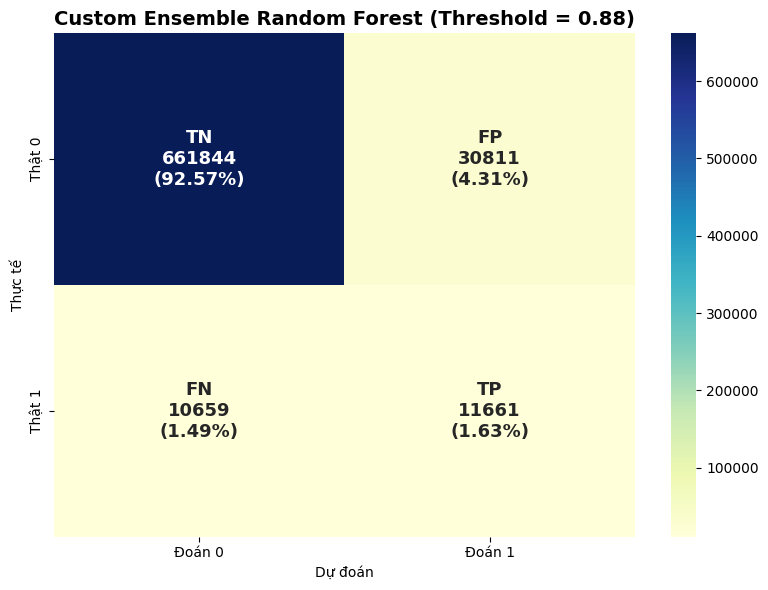

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

print(f"Bắt đầu huấn luyện hệ thống Ensemble với {len(balanced_datasets)} mô hình con...\n")

# 1. TẠO DANH SÁCH CHỨA CÁC MÔ HÌNH ĐÃ TRAIN
ensemble_models = []

# Huấn luyện từng mô hình trên từng bộ dữ liệu con
for i, (X_batch, y_batch) in enumerate(balanced_datasets):
    # Khởi tạo một Random Forest nhỏ (50 cây là đủ vì ta sẽ có n mô hình)
    # Không cần dùng class_weight='balanced' nữa vì dữ liệu X_batch đã tự cân bằng 1:1 rồi!
    rf = RandomForestClassifier(
        n_estimators=50, 
        max_depth=10, 
        random_state=42 + i,
         class_weight='balanced', 
        n_jobs=-1
    )
    
    # Train mô hình
    rf.fit(X_batch, y_batch)
    
    # Lưu mô hình vào danh sách
    ensemble_models.append(rf)
    print(f"[*] Đã huấn luyện xong mô hình thứ {i+1}/{len(balanced_datasets)}")

# ==========================================
# 2. DỰ ĐOÁN BẰNG CÁCH BỎ PHIẾU (SOFT VOTING)
# ==========================================
print("\nĐang tiến hành Bỏ phiếu trung bình (Soft Voting) trên tập Test...")

# Lấy xác suất dự đoán của TẤT CẢ các mô hình trên tập X_test
all_predictions = []
for model in ensemble_models:
    prob = model.predict_proba(X_test)[:, 1]
    all_predictions.append(prob)

# Tính trung bình cộng xác suất của tất cả mô hình (Soft Voting)
# Ví dụ: 30 mô hình bảo mua, 10 mô hình bảo không -> Xác suất sẽ nghiêng về mua
y_prob_ensemble = np.mean(all_predictions, axis=0)

# ==========================================
# 3. TỰ ĐỘNG TÌM NGƯỠNG TỐI ƯU CHO HỆ THỐNG ENSEMBLE
# ==========================================
print("Đang dò tìm Threshold tối ưu cho hệ thống Ensemble...")

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.01, 1.00, 0.01)

for thresh in thresholds:
    y_pred_temp = (y_prob_ensemble >= thresh).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"\n=> NGƯỠNG TỐI ƯU CỦA ENSEMBLE LÀ: {best_threshold:.2f}")
print(f"=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: {best_f1:.4f}\n")

# ==========================================
# 4. ĐÁNH GIÁ VÀ VẼ MA TRẬN NHẦM LẪN
# ==========================================
y_pred_final = (y_prob_ensemble >= best_threshold).astype(int)

print(f"=== BÁO CÁO PHÂN LỚP (NGƯỠNG = {best_threshold:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}\n")
print(classification_report(y_test, y_pred_final))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
cm_percentage = cm.astype('float') / cm.sum() * 100

labels = [f"TN\n{cm[0,0]}\n({cm_percentage[0,0]:.2f}%)",
          f"FP\n{cm[0,1]}\n({cm_percentage[0,1]:.2f}%)",
          f"FN\n{cm[1,0]}\n({cm_percentage[1,0]:.2f}%)",
          f"TP\n{cm[1,1]}\n({cm_percentage[1,1]:.2f}%)"]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='YlGnBu',
            xticklabels=['Đoán 0', 'Đoán 1'], yticklabels=['Thật 0', 'Thật 1'],
            annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Custom Ensemble Random Forest (Threshold = {best_threshold:.2f})', fontsize=14, fontweight='bold')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig('custom_ensemble_confusion_matrix.png', dpi=300)
plt.show()

In [63]:
bundle={
'threshold':best_threshold,
'model':ensemble_models 
}
joblib.dump(bundle,'Decision_tree_Esemble.pkl')

['Decision_tree_Esemble.pkl']

In [64]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Tách Features (X) và Target (y)
# Cột user_session là ID chuỗi nên phải bỏ đi để mô hình chạy được
X = train_data.drop(columns=['user_session', 'is_purchased'])
y = train_data['is_purchased']

# 2. Chia tập Train/Test (Dành 20% dữ liệu để kiểm thử)
# LƯU Ý QUAN TRỌNG: stratify=y giúp đảm bảo tỷ lệ 3% nhãn '1' được chia đều cho cả tập Train và Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Tính toán trọng số tự động cho lớp thiểu số
# Trọng số = (Tổng số dòng nhãn 0) / (Tổng số dòng nhãn 1)
# Với tỷ lệ 3%, con số này sẽ rơi vào khoảng ~32
weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Trọng số phạt (scale_pos_weight) tự động tính là: {weight:.2f}")

# 4. Khởi tạo mô hình LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,        # Số lượng cây quyết định (tăng độ phức tạp)
    learning_rate=0.05,      # Tốc độ học (nhỏ một chút để mô hình học kỹ hơn)
    scale_pos_weight=weight, # <-- "VŨ KHÍ" QUAN TRỌNG NHẤT XỬ LÝ MẤT CÂN BẰNG
    random_state=42,
    n_jobs=-1                # Huy động 100% sức mạnh CPU để chạy cho nhanh
)

# 5. Huấn luyện mô hình
print("Đang huấn luyện mô hình LightGBM... Bạn đợi một chút nhé!")
lgb_model.fit(X_train, y_train)

# 6. Dự đoán trên tập Test
y_pred_lgb = lgb_model.predict(X_test)

# 7. Đánh giá mô hình
print("\n--- KẾT QUẢ ĐÁNH GIÁ LIGHTGBM ---")
print("Báo cáo phân loại (Chú ý cột Recall và F1-score của lớp 1):")
print(classification_report(y_test, y_pred_lgb))

print("Ma trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_lgb))

Trọng số phạt (scale_pos_weight) tự động tính là: 31.03
Đang huấn luyện mô hình LightGBM... Bạn đợi một chút nhé!
[LightGBM] [Info] Number of positive: 89278, number of negative: 2770618
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 2859896, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031217 -> initscore=-3.435071
[LightGBM] [Info] Start training from score -3.435071

--- KẾT QUẢ ĐÁNH GIÁ LIGHTGBM ---
Báo cáo phân loại (Chú ý cột Recall và F1-score của lớp 1):
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    692655
           1       0.16      0.93      0.27     22320

    accuracy                           0.84    714975
   macro avg

In [65]:

joblib.dump(lgb_model,'lgb_model.pkl')

['lgb_model.pkl']

In [66]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix

# 1. Tách Features (X) và Target (y)
X = train_data.drop(columns=['user_session', 'is_purchased'])
y = train_data['is_purchased']

# 2. CHIA TẬP TRAIN/TEST (Luôn giữ 20% làm tập Test thuần khiết)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. CHUẨN BỊ CHIA NHỎ LỚP 0 TRONG TẬP TRAIN
# Gộp X_train và y_train lại tạm thời
train_temp = pd.concat([X_train, y_train], axis=1)

# Tách riêng lớp 0 và lớp 1
class_0 = train_temp[train_temp['is_purchased'] == 0]
class_1 = train_temp[train_temp['is_purchased'] == 1]

# Xáo trộn lớp 0 ngẫu nhiên trước khi cắt khúc
class_0 = shuffle(class_0, random_state=42)

n_models = 10

# Chia danh sách các vị trí (từ 0 đến tổng số dòng) thành 10 phần
chunk_positions = np.array_split(range(len(class_0)), n_models)

# Dùng iloc để trích xuất lại DataFrame từ các vị trí đó
class_0_chunks = [class_0.iloc[pos] for pos in chunk_positions]

print(f"Tổng số dòng lớp 1 (giữ nguyên cho mọi mô hình): {len(class_1)}")
print(f"Tổng số dòng lớp 0 trong mỗi chunk: {len(class_0_chunks[0])}")
# 5. HUẤN LUYỆN 10 MÔ HÌNH LIGHTGBM 
models = [] # Danh sách chứa 10 mô hình

for i, class_0_chunk in enumerate(class_0_chunks):
    print(f"Đang huấn luyện mô hình thứ {i+1}/{n_models}...")
    
    # Gộp 1 chunk của lớp 0 với toàn bộ lớp 1
    chunk_data = pd.concat([class_0_chunk, class_1], axis=0)
    chunk_data = shuffle(chunk_data, random_state=42+i) # Trộn đều
    
    X_train_chunk = chunk_data.drop(columns=['is_purchased'])
    y_train_chunk = chunk_data['is_purchased']
    
    # Tính trọng số phạt cho chunk này (Vì tỷ lệ giờ là khoảng 3:1 chứ không còn là 32:1 nữa)
    weight = len(class_0_chunk) / len(class_1)
    
    # Khởi tạo mô hình
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=weight, # Cân bằng tỷ lệ 3:1
        random_state=42,
        n_jobs=-1
    )
    
    # Huấn luyện và lưu vào danh sách
    model.fit(X_train_chunk, y_train_chunk)
    models.append(model)

print("\nĐã huấn luyện xong toàn bộ hội đồng 10 mô hình!")

# 6. DỰ ĐOÁN BẰNG CÁCH BỎ PHIẾU (SOFT VOTING)
# Tạo một mảng toàn số 0 để cộng dồn xác suất từ 10 mô hình
ensemble_probs = np.zeros(len(X_test))

print("Đang tiến hành cho 10 mô hình bỏ phiếu trên tập Test...")
for model in models:
    # Lấy xác suất dự đoán là lớp 1 của từng mô hình rồi cộng dồn lại
    ensemble_probs += model.predict_proba(X_test)[:, 1]

# Chia trung bình để ra xác suất cuối cùng
ensemble_probs /= n_models

# 7. CHỐT KẾT QUẢ VÀ ĐÁNH GIÁ
# Ngưỡng dự đoán (Threshold). Mặc định là 0.5, bạn có thể chỉnh lên 0.6, 0.7...
threshold = 0.5
y_pred_ensemble = (ensemble_probs >= threshold).astype(int)

print(f"\n--- KẾT QUẢ ENSEMBLE (THRESHOLD = {threshold}) ---")
print(classification_report(y_test, y_pred_ensemble))
print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred_ensemble))

Tổng số dòng lớp 1 (giữ nguyên cho mọi mô hình): 89278
Tổng số dòng lớp 0 trong mỗi chunk: 277062
Đang huấn luyện mô hình thứ 1/10...
[LightGBM] [Info] Number of positive: 89278, number of negative: 277062
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1355
[LightGBM] [Info] Number of data points in the train set: 366340, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.243703 -> initscore=-1.132486
[LightGBM] [Info] Start training from score -1.132486
Đang huấn luyện mô hình thứ 2/10...
[LightGBM] [Info] Number of positive: 89278, number of negative: 277062
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can 

In [67]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

print("--- TÌM KIẾM NGƯỠNG (THRESHOLD) TỐI ƯU ---")

# Thử các ngưỡng từ 0.5 đến 0.9, bước nhảy 0.05
thresholds = np.arange(0.5, 0.95, 0.05)

for t in thresholds:
    # Biến xác suất thành nhãn 0/1 dựa trên ngưỡng t
    y_pred_t = (ensemble_probs >= t).astype(int)
    
    # Tính toán các chỉ số cho lớp 1
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    # In kết quả
    print(f"Ngưỡng {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1-Score: {f1:.3f}")

--- TÌM KIẾM NGƯỠNG (THRESHOLD) TỐI ƯU ---
Ngưỡng 0.50 | Precision: 0.154 | Recall: 0.927 | F1-Score: 0.265
Ngưỡng 0.55 | Precision: 0.162 | Recall: 0.917 | F1-Score: 0.275
Ngưỡng 0.60 | Precision: 0.167 | Recall: 0.906 | F1-Score: 0.283
Ngưỡng 0.65 | Precision: 0.175 | Recall: 0.891 | F1-Score: 0.292
Ngưỡng 0.70 | Precision: 0.187 | Recall: 0.859 | F1-Score: 0.307
Ngưỡng 0.75 | Precision: 0.207 | Recall: 0.804 | F1-Score: 0.329
Ngưỡng 0.80 | Precision: 0.233 | Recall: 0.721 | F1-Score: 0.352
Ngưỡng 0.85 | Precision: 0.265 | Recall: 0.609 | F1-Score: 0.369
Ngưỡng 0.90 | Precision: 0.323 | Recall: 0.417 | F1-Score: 0.364


In [68]:
threshold = 0.85
y_pred_ensemble = (ensemble_probs >= threshold).astype(int)

print(f"\n--- KẾT QUẢ ENSEMBLE (THRESHOLD = {threshold}) ---")
print(classification_report(y_test, y_pred_ensemble))
print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred_ensemble))


--- KẾT QUẢ ENSEMBLE (THRESHOLD = 0.85) ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    692655
           1       0.27      0.61      0.37     22320

    accuracy                           0.94    714975
   macro avg       0.63      0.78      0.67    714975
weighted avg       0.96      0.94      0.95    714975

Ma trận nhầm lẫn:
[[655004  37651]
 [  8734  13586]]


In [70]:
bundle={
'threshold':0.85,
'models':models
}
joblib.dump(bundle,'lightbgm_esemble.pkl')

['lightbgm_esemble.pkl']

Đang huấn luyện mô hình LightGBM Cơ bản (Không xử lý mất cân bằng)...
[LightGBM] [Info] Number of positive: 89278, number of negative: 2770618
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.134615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 2859896, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031217 -> initscore=-3.435071
[LightGBM] [Info] Start training from score -3.435071
Đang dò tìm Threshold tối ưu cho mô hình Baseline...

=> NGƯỠNG TỐI ƯU CỦA BASELINE LÀ: 0.18
=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: 0.3745

=== BÁO CÁO PHÂN LỚP LIGHTGBM BASELINE (NGƯỠNG = 0.18) ===
Accuracy: 0.9431

              precision    recall  f1-score   support

           0       0.98      0.96      0.97    692655
           1       0.29      0.55      0.37     223

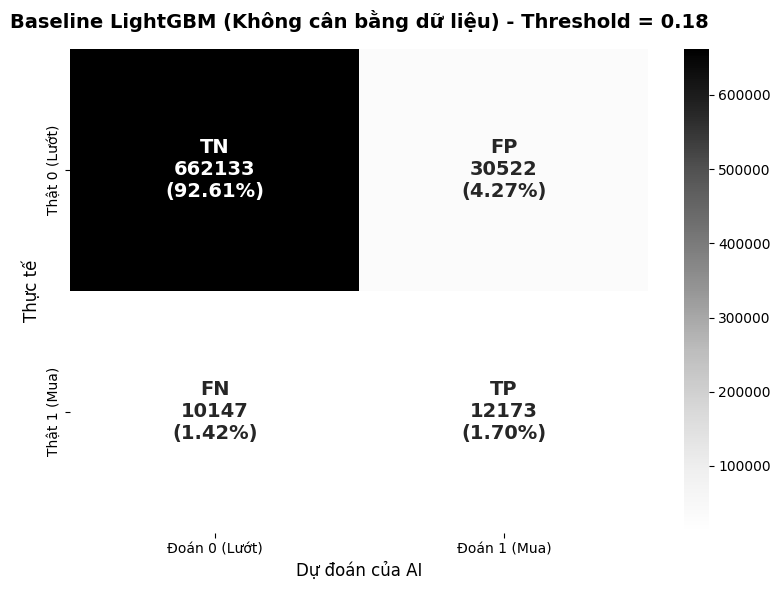

In [51]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# ==========================================
# 1. HUẤN LUYỆN LIGHTGBM "NGUYÊN THỦY" (BASELINE)
# ==========================================
print("Đang huấn luyện mô hình LightGBM Cơ bản (Không xử lý mất cân bằng)...")

# Tuyệt đối KHÔNG DÙNG scale_pos_weight hay class_weight='balanced'
lgb_baseline = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# Huấn luyện trực tiếp trên toàn bộ X_train gốc (Tỷ lệ 31:1)
lgb_baseline.fit(X_train, y_train)

# Lấy xác suất dự đoán Lớp 1
y_prob_baseline = lgb_baseline.predict_proba(X_test)[:, 1]

# ==========================================
# 2. TỰ ĐỘNG DÒ TÌM NGƯỠNG TỐI ƯU
# ==========================================
print("Đang dò tìm Threshold tối ưu cho mô hình Baseline...")

best_threshold_base = 0.5
best_f1_base = 0
thresholds = np.arange(0.01, 1.00, 0.01)

for thresh in thresholds:
    y_pred_temp = (y_prob_baseline >= thresh).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    
    if current_f1 > best_f1_base:
        best_f1_base = current_f1
        best_threshold_base = thresh

print(f"\n=> NGƯỠNG TỐI ƯU CỦA BASELINE LÀ: {best_threshold_base:.2f}")
print(f"=> F1-SCORE CAO NHẤT ĐẠT ĐƯỢC: {best_f1_base:.4f}\n")

# ==========================================
# 3. ĐÁNH GIÁ VÀ VẼ MA TRẬN NHẦM LẪN
# ==========================================
y_pred_base_final = (y_prob_baseline >= best_threshold_base).astype(int)

print(f"=== BÁO CÁO PHÂN LỚP LIGHTGBM BASELINE (NGƯỠNG = {best_threshold_base:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base_final):.4f}\n")
print(classification_report(y_test, y_pred_base_final))

# Vẽ Ma trận nhầm lẫn (Dùng màu xám/đen để phân biệt với mô hình chính)
cm_base = confusion_matrix(y_test, y_pred_base_final)
cm_percentage_base = cm_base.astype('float') / cm_base.sum() * 100

labels_base = [f"TN\n{cm_base[0,0]}\n({cm_percentage_base[0,0]:.2f}%)",
               f"FP\n{cm_base[0,1]}\n({cm_percentage_base[0,1]:.2f}%)",
               f"FN\n{cm_base[1,0]}\n({cm_percentage_base[1,0]:.2f}%)",
               f"TP\n{cm_base[1,1]}\n({cm_percentage_base[1,1]:.2f}%)"]
labels_base = np.asarray(labels_base).reshape(2,2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_base, annot=labels_base, fmt='', cmap='Greys',
            xticklabels=['Đoán 0 (Lướt)', 'Đoán 1 (Mua)'], 
            yticklabels=['Thật 0 (Lướt)', 'Thật 1 (Mua)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title(f'Baseline LightGBM (Không cân bằng dữ liệu) - Threshold = {best_threshold_base:.2f}', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Thực tế', fontsize=12)
plt.xlabel('Dự đoán của AI', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_lightgbm_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
import joblib as jl
